# Initial imports and connect google drive

In [1]:
#necessary imports
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

In [2]:
#connect
drive.mount('/content/drive')

Mounted at /content/drive


#Read the data


In [5]:
#READ XLSL PRODUCCION

#define the route
produccion_final = "https://docs.google.com/spreadsheets/d/1-J4MMRT4mgxuwUdiUK2hLd7pR-11UD_L/export?format=xlsx"

#read the xlsl
df_produccion = pd.read_excel(produccion_final)

#show rows
display(df_produccion)

,año,ANDALUCIA,CATALUÑA,CENTRO,NORTE,OESTE
0,2007,9655075.000,9.604339e+06,1.701540e+07,5665157.00,8123077.00
1,2008,7548550.000,7.003805e+06,1.289381e+07,4326972.00,6995642.00
2,2009,5309281.000,5.223182e+06,8.112775e+06,3430356.00,5447282.34
3,2010,4787920.460,5.110303e+06,6.847098e+06,2967544.67,4835287.22
4,2011,4265750.000,4.069060e+06,5.846899e+06,2732392.00,3806660.79
5,2012,2580897.092,3.024038e+06,4.034846e+06,2145904.00,2849663.00
6,2013,2869259.620,2.104112e+06,3.278801e+06,1710011.96,2498245.90
7,2014,2789326.330,2.355427e+06,3.452050e+06,1815005.38,2728598.20
8,2015,2845860.110,2.403932e+06,3.717052e+06,1824588.00,2709423.00
9,2016,2858150.900,2.653309e+06,3.574881e+06,1936935.00,2447443.01


In [3]:
#READ XLSL FABRICAS

#define the route
fabricas_final = "https://docs.google.com/spreadsheets/d/1-0o3QYSokCJ34P5vGufZHJSx0y75g0Ar/export?format=xlsx"

#read the xlsl
df_fabricas = pd.read_excel(fabricas_final)

#show rows
display(df_fabricas)

,region,localizacion,comunidad_autonoma,fabrica,cod_fabrica,capacidad_produccion,n_fabricas_region,n_fabricas_ccaa
0,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1
1,OESTE,Toral de los Vados - León,Castilla y León,"Votorantim Cementos España, S.A.",ES.CAED/001497000.FACILITY,1600000,6,3
2,OESTE,La Robla - León,Castilla y León,"Cementos Tudela Veguín, S.A.",ES.CAED/001916000.FACILITY,850000,6,3
3,OESTE,Hontoria - Venta de Baños - Palencia,Castilla y León,"Cementos Portland Valderrivas, S.A.",ES.CAED/001758000.FACILITY,1200000,6,3
4,OESTE,Aboño - Carreño - Oviedo,Asturias,"Cementos Tudela Veguín, S.A.",ES.CAED/001915000.FACILITY,2400000,6,1
5,OESTE,Mataporquera - Cantabria,Cantabria,"Cementos Alfa, S.A.",ES.CAED/002072000.FACILITY,1050000,6,1
6,NORTE,Arrigorriaga - Vizcaya,País Vasco,"Heidelberg Materials Hispania Cementos, S.A.",ES.CAED/003686000.FACILITY,1125000,5,3
7,NORTE,Lemona - Vizcaya,País Vasco,"Cementos Lemona, S.A.",ES.CAED/003718000.FACILITY,1250000,5,3
8,NORTE,Añorga - Guipúzcoa,País Vasco,"Heidelberg Materials Hispania Cementos, S.A.",ES.CAED/003687000.FACILITY,1050000,5,3
9,NORTE,Olazagutía - Navarra,Navarra,"Cementos Portland Valderrivas, S.A.",ES.CAED/001760000.FACILITY,1300000,5,1


In [ ]:
#total number of factories
print(len(df_fabricas.cod_fabrica.unique()))

28


In [4]:
#READ XLSL EMISIONES

#define the route
emisiones_final = "https://docs.google.com/spreadsheets/d/1-Apk9nR_XJI0MNg7LDz5-Qa1cQLAy4eP/export?format=xlsx"

#read the xlsl
df_emisiones = pd.read_excel(emisiones_final)

#show rows
display(df_emisiones)

,countryName,EPRTRSectorCode,eprtrSectorName,EPRTRAnnexIMainActivityCode,EPRTRAnnexIMainActivityLabel,FacilityInspireID,facilityName,Longitude,Latitude,City,targetRelease,pollutant,emissions,reportingYear
0,Spain,3,Mineral industry,3(c)(i),Installations for the production of cement cli...,ES.CAED/000121000.FACILITY,A.G. CEMENTOS BALBOA,-6.483457,38.378807,ALCONERA,AIR,Carbon dioxide (CO2),7.830000e+08,2007
1,Spain,3,Mineral industry,3(c)(i),Installations for the production of cement cli...,ES.CAED/000121000.FACILITY,A.G. CEMENTOS BALBOA,-6.483457,38.378807,ALCONERA,AIR,Chlorine and inorganic compounds (as HCl),1.380000e+04,2007
2,Spain,3,Mineral industry,3(c)(i),Installations for the production of cement cli...,ES.CAED/000121000.FACILITY,A.G. CEMENTOS BALBOA,-6.483457,38.378807,ALCONERA,AIR,Mercury and compounds (as Hg),1.300000e+01,2007
3,Spain,3,Mineral industry,3(c)(i),Installations for the production of cement cli...,ES.CAED/000121000.FACILITY,A.G. CEMENTOS BALBOA,-6.483457,38.378807,ALCONERA,AIR,Nitrogen oxides (NOX),2.700000e+06,2007
4,Spain,3,Mineral industry,3(c)(i),Installations for the production of cement cli...,ES.CAED/000141000.FACILITY,LAFARGEHOLCIM ESPAÑA SAU - SAGUNTO (FABRICA DE...,-0.245249,39.666318,PUERTO (EL),AIR,Carbon dioxide (CO2),1.040000e+09,2007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2087,Spain,3,Mineral industry,3(c)(i),Installations for the production of cement cli...,ES.CAED/003718000.FACILITY,"LEMONA INDUSTRIAL, S.A. (LEMONA INDUSTRIAL, S.A)",-2.771422,43.206875,ESTAZIÑOA,AIR,Carbon dioxide (CO2),3.870000e+08,2022
2088,Spain,3,Mineral industry,3(c)(i),Installations for the production of cement cli...,ES.CAED/003718000.FACILITY,"LEMONA INDUSTRIAL, S.A. (LEMONA INDUSTRIAL, S.A)",-2.771422,43.206875,ESTAZIÑOA,AIR,Carbon monoxide (CO),2.450000e+06,2022
2089,Spain,3,Mineral industry,3(c)(i),Installations for the production of cement cli...,ES.CAED/003718000.FACILITY,"LEMONA INDUSTRIAL, S.A. (LEMONA INDUSTRIAL, S.A)",-2.771422,43.206875,ESTAZIÑOA,AIR,Mercury and compounds (as Hg),1.180000e+01,2022
2090,Spain,3,Mineral industry,3(c)(i),Installations for the production of cement cli...,ES.CAED/003718000.FACILITY,"LEMONA INDUSTRIAL, S.A. (LEMONA INDUSTRIAL, S.A)",-2.771422,43.206875,ESTAZIÑOA,AIR,Nitrogen oxides (NOX),6.320000e+05,2022


# Merging of the datatsets

In [ ]:
#merge of factories and emissions by the code
df_medio = pd.merge(df_fabricas, df_emisiones, left_on='cod_fabrica', right_on='FacilityInspireID')

#drop columns that will be unused
df_medio.drop(columns=['FacilityInspireID', 'countryName', 'EPRTRSectorCode', 'eprtrSectorName', 'EPRTRAnnexIMainActivityLabel',
                       'EPRTRAnnexIMainActivityCode', 'facilityName', 'Longitude', 'Latitude', 'City', 'targetRelease', 'pollutant'], inplace=True)

#show the results
print(df_medio.shape)
display(df_medio)

(1860, 10)


,region,localizacion,comunidad_autonoma,fabrica,cod_fabrica,capacidad_produccion,n_fabricas_region,n_fabricas_ccaa,emissions,reportingYear
0,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1,370000000.0,2007
1,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1,1080000.0,2007
2,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1,376000000.0,2008
3,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1,40.0,2008
4,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1,1140000.0,2008
...,...,...,...,...,...,...,...,...,...,...
1855,ANDALUCIA,Carboneras - Almería,Andalucía,"Holcim España, S.A.U.",ES.CAED/001573000.FACILITY,1500000,6,6,1100000.0,2021
1856,ANDALUCIA,Carboneras - Almería,Andalucía,"Holcim España, S.A.U.",ES.CAED/001573000.FACILITY,1500000,6,6,983000.0,2021
1857,ANDALUCIA,Carboneras - Almería,Andalucía,"Holcim España, S.A.U.",ES.CAED/001573000.FACILITY,1500000,6,6,649000000.0,2022
1858,ANDALUCIA,Carboneras - Almería,Andalucía,"Holcim España, S.A.U.",ES.CAED/001573000.FACILITY,1500000,6,6,627000.0,2022


In [6]:
#transform the production dataset to easily merge
df_produccion_vertical = df_produccion.melt(id_vars=[ "año"], var_name="region", value_name="produccion_region")
display(df_produccion_vertical)

,año,region,produccion_region
0,2007,ANDALUCIA,9655075.00
1,2008,ANDALUCIA,7548550.00
2,2009,ANDALUCIA,5309281.00
3,2010,ANDALUCIA,4787920.46
4,2011,ANDALUCIA,4265750.00
...,...,...,...
75,2018,OESTE,2746240.36
76,2019,OESTE,2840641.14
77,2020,OESTE,2587438.23
78,2021,OESTE,3055073.24


In [ ]:
#rename its year column
df_medio.rename(columns={'reportingYear': 'año'}, inplace=True)

#merge the previous dataset and production dataset by the year and region
df_merged = pd.merge(df_medio, df_produccion_vertical, on=["region", "año"], how="left")

display(df_merged)

,region,localizacion,comunidad_autonoma,fabrica,cod_fabrica,capacidad_produccion,n_fabricas_region,n_fabricas_ccaa,emissions,año,produccion_region
0,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1,370000000.0,2007,8123077.0
1,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1,1080000.0,2007,8123077.0
2,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1,376000000.0,2008,6995642.0
3,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1,40.0,2008,6995642.0
4,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1,1140000.0,2008,6995642.0
...,...,...,...,...,...,...,...,...,...,...,...
1855,ANDALUCIA,Carboneras - Almería,Andalucía,"Holcim España, S.A.U.",ES.CAED/001573000.FACILITY,1500000,6,6,1100000.0,2021,3605411.0
1856,ANDALUCIA,Carboneras - Almería,Andalucía,"Holcim España, S.A.U.",ES.CAED/001573000.FACILITY,1500000,6,6,983000.0,2021,3605411.0
1857,ANDALUCIA,Carboneras - Almería,Andalucía,"Holcim España, S.A.U.",ES.CAED/001573000.FACILITY,1500000,6,6,649000000.0,2022,3605411.0
1858,ANDALUCIA,Carboneras - Almería,Andalucía,"Holcim España, S.A.U.",ES.CAED/001573000.FACILITY,1500000,6,6,627000.0,2022,3605411.0


#Production per factory by their emissions calculation

In [ ]:
#dataset to modify
df = df_merged

In [ ]:
#calcluate the total emissions for each region, each year
df['emisiones_totales_region'] = df.groupby(['region', 'año'])['emissions'].transform('sum')

#calculate the total emissions for each ccaa, each year
df['emisiones_totales_ccaa'] = df.groupby(['comunidad_autonoma', 'año'])['emissions'].transform('sum')

In [ ]:
#calculate the weight of each facotry in its region based on its capacity
df["peso_fabrica"] = df["capacidad_produccion"] / df.groupby(["region", "año"])["capacidad_produccion"].transform("sum")

#CALCULATE THE PRODUCTION OF EACH FACTORY BY ITS EMISSIONS AND CAPACITY
df["produccion_fabrica"] = df["peso_fabrica"] * (df["emissions"] / df["emisiones_totales_region"]) * df["produccion_region"]

In [ ]:
#get the total capacity of production of each region
capacidad_total_region = df.groupby(["region", "año"])["capacidad_produccion"].sum().reset_index(name="capacidad_total_region")
df = df.merge(capacidad_total_region, on=["region", "año"], how="left")

In [ ]:
#get the total capacity of production of each ccaa
capacidad_total_ccaa = df.groupby(["comunidad_autonoma", "año"])["capacidad_produccion"].sum().reset_index(name="capacidad_total_ccaa")
df = df.merge(capacidad_total_ccaa, on=["comunidad_autonoma", "año"], how="left")

In [ ]:
#calculate the producction for each ccaa (sum of its factories' production)
produccion_ccaa= df.groupby(["comunidad_autonoma", "año"])["produccion_fabrica"].sum().reset_index(name="produccion_ccaa")
df = df.merge(produccion_ccaa, on=["comunidad_autonoma", "año"], how="left")

In [ ]:
#make unique codes for each ccaa just in case
codigos_unicos = {ccaa: f"{ccaa[0]}{i+1}" for i, ccaa in enumerate(df['comunidad_autonoma'].unique())}
df['codigo_ccaa'] = df['comunidad_autonoma'].map(codigos_unicos)

In [ ]:
display(df)

,region,localizacion,comunidad_autonoma,fabrica,cod_fabrica,capacidad_produccion,n_fabricas_region,n_fabricas_ccaa,emissions,año,produccion_region,emisiones_totales_region,emisiones_totales_ccaa,peso_fabrica,produccion_fabrica,capacidad_total_region,capacidad_total_ccaa,produccion_ccaa,codigo_ccaa
0,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1,370000000.0,2007,8123077.0,4.312483e+09,3.710800e+08,0.016209,11297.018792,40100000,1300000,11329.993874,G1
1,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1,1080000.0,2007,8123077.0,4.312483e+09,3.710800e+08,0.016209,32.975082,40100000,1300000,11329.993874,G1
2,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1,376000000.0,2008,6995642.0,3.727511e+09,3.771401e+08,0.009400,6633.117616,69150000,2600000,6653.230993,G1
3,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1,40.0,2008,6995642.0,3.727511e+09,3.771401e+08,0.009400,0.000706,69150000,2600000,6653.230993,G1
4,OESTE,Oural-Lugo,Galicia,"Votorantim Cementos España, S.A.",ES.CAED/001496000.FACILITY,650000,6,1,1140000.0,2008,6995642.0,3.727511e+09,3.771401e+08,0.009400,20.111048,69150000,2600000,6653.230993,G1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1855,ANDALUCIA,Carboneras - Almería,Andalucía,"Holcim España, S.A.U.",ES.CAED/001573000.FACILITY,1500000,6,6,1100000.0,2021,3605411.0,1.957285e+09,1.957285e+09,0.065646,133.014340,22850000,22850000,205529.316023,A13
1856,ANDALUCIA,Carboneras - Almería,Andalucía,"Holcim España, S.A.U.",ES.CAED/001573000.FACILITY,1500000,6,6,983000.0,2021,3605411.0,1.957285e+09,1.957285e+09,0.065646,118.866451,22850000,22850000,205529.316023,A13
1857,ANDALUCIA,Carboneras - Almería,Andalucía,"Holcim España, S.A.U.",ES.CAED/001573000.FACILITY,1500000,6,6,649000000.0,2022,3605411.0,1.648827e+09,1.648827e+09,0.102740,145801.745484,14600000,14600000,342442.560084,A13
1858,ANDALUCIA,Carboneras - Almería,Andalucía,"Holcim España, S.A.U.",ES.CAED/001573000.FACILITY,1500000,6,6,627000.0,2022,3605411.0,1.648827e+09,1.648827e+09,0.102740,140.859313,14600000,14600000,342442.560084,A13


In [ ]:
#checking that the sum of each factory's weight is 1 in its region
(df.groupby(["region", "año"])["peso_fabrica"].sum() - 1).abs().max()

0.0

In [ ]:
#checking that the sum for each ccaa's production is correct
(df.groupby(['comunidad_autonoma', 'año'])['produccion_fabrica'].sum() == df.groupby(['comunidad_autonoma', 'año'])['produccion_ccaa'].first()).all()

np.True_

# Total production and emissiones per CCAA by year

In [ ]:
#selecting the ccaa columns for plotting
df_resumen_ccaa = df[["region", "año", "codigo_ccaa", "comunidad_autonoma", "n_fabricas_ccaa",
                       "emisiones_totales_ccaa", "produccion_ccaa", "capacidad_total_ccaa"]].drop_duplicates()

display(df_resumen_ccaa)

,region,año,codigo_ccaa,comunidad_autonoma,n_fabricas_ccaa,emisiones_totales_ccaa,produccion_ccaa,capacidad_total_ccaa
0,OESTE,2007,G1,Galicia,1,3.710800e+08,11329.993874,1300000
2,OESTE,2008,G1,Galicia,1,3.771401e+08,6653.230993,2600000
6,OESTE,2009,G1,Galicia,1,3.544931e+08,6781.446721,3250000
11,OESTE,2010,G1,Galicia,1,3.346541e+08,6244.404108,3250000
16,OESTE,2011,G1,Galicia,1,2.552291e+08,5464.417940,3250000
...,...,...,...,...,...,...,...,...
1518,ANDALUCIA,2018,A13,Andalucía,6,3.330125e+09,115511.466262,35600000
1522,ANDALUCIA,2019,A13,Andalucía,6,2.908281e+09,133108.105681,31200000
1525,ANDALUCIA,2020,A13,Andalucía,6,2.832824e+09,137135.683126,30200000
1528,ANDALUCIA,2021,A13,Andalucía,6,1.957285e+09,205529.316023,22850000


In [ ]:
df['comunidad_autonoma'].unique()

array(['Galicia', 'Castilla y León', 'Asturias', 'Cantabria',
       'País Vasco', 'Navarra', 'Aragón', 'Cataluña', 'Madrid',
       'Castilla La Mancha', 'Comunitat Valenciana', 'Extremadura',
       'Andalucía'], dtype=object)

In [ ]:
#check all years are in order
df_resumen_ccaa = df_resumen_ccaa.sort_values(by=['comunidad_autonoma', 'año'], ascending=[True, True])
df_resumen_ccaa.reset_index(drop=True, inplace=True)
df_resumen_ccaa

,region,año,codigo_ccaa,comunidad_autonoma,n_fabricas_ccaa,emisiones_totales_ccaa,produccion_ccaa,capacidad_total_ccaa
0,ANDALUCIA,2007,A13,Andalucía,6,3.664278e+09,284687.118023,46650000
1,ANDALUCIA,2008,A13,Andalucía,6,3.562673e+09,261767.592021,39675000
2,ANDALUCIA,2009,A13,Andalucía,6,3.040801e+09,233187.669157,29850000
3,ANDALUCIA,2010,A13,Andalucía,6,3.210433e+09,169346.960186,36600000
4,ANDALUCIA,2011,A13,Andalucía,6,2.834643e+09,206491.439358,27550000
...,...,...,...,...,...,...,...,...
197,NORTE,2018,P5,País Vasco,3,1.085488e+09,59207.228595,16400000
198,NORTE,2019,P5,País Vasco,3,7.406115e+08,69387.734366,14225000
199,NORTE,2020,P5,País Vasco,3,7.954808e+08,56786.986195,12775000
200,NORTE,2021,P5,País Vasco,3,9.758621e+08,66255.290453,16200000


# Plot for each CCAA

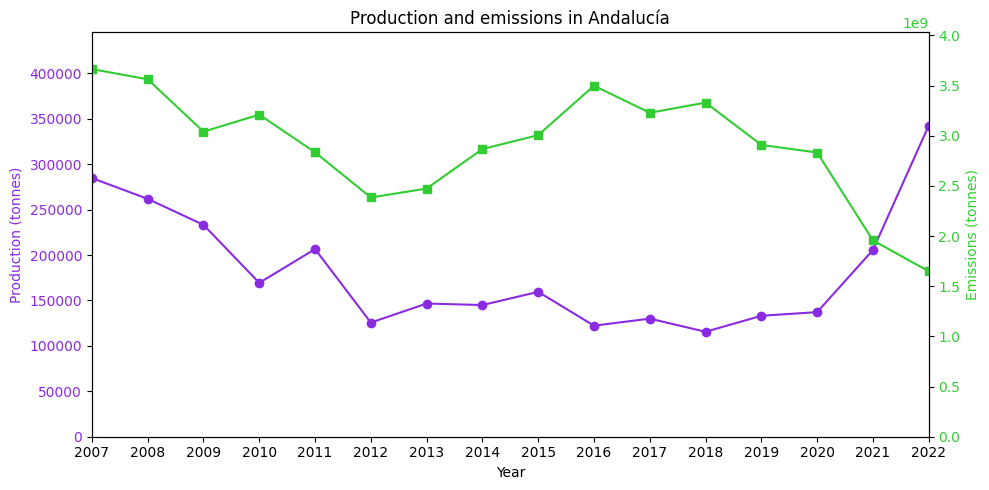

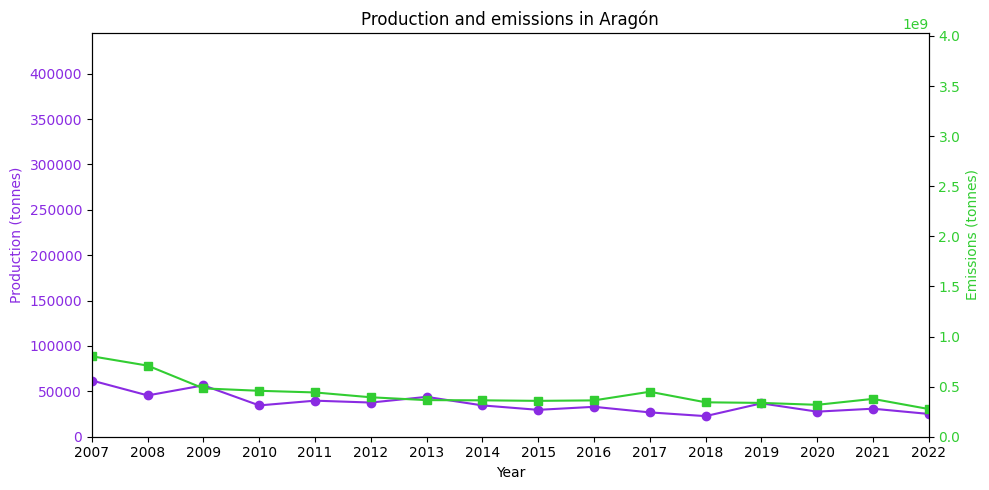

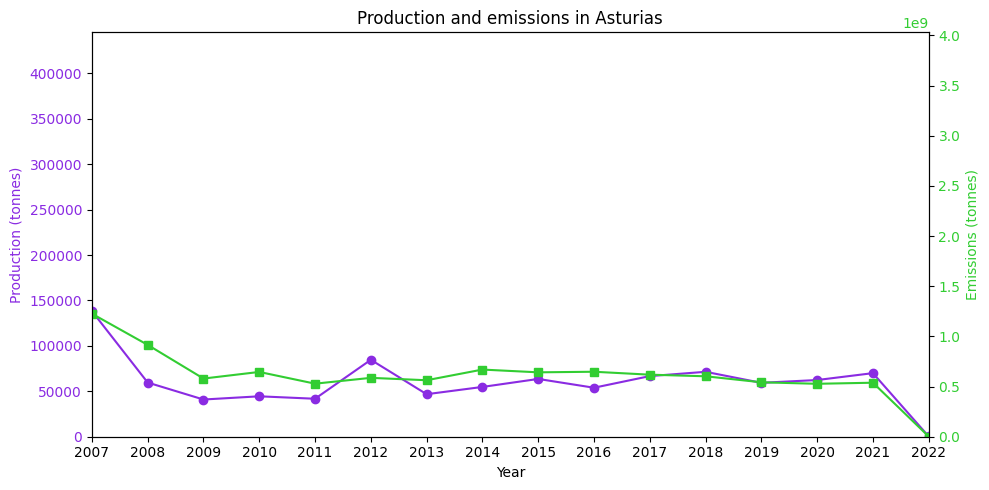

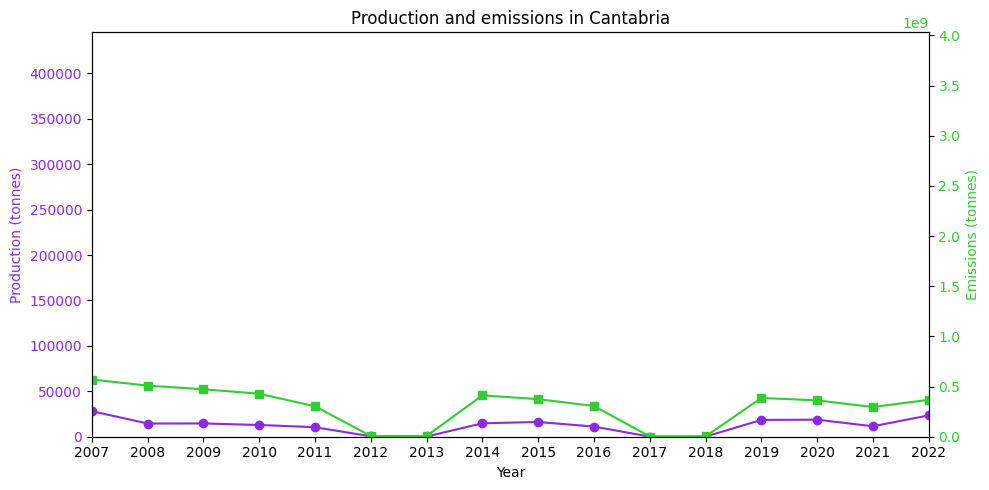

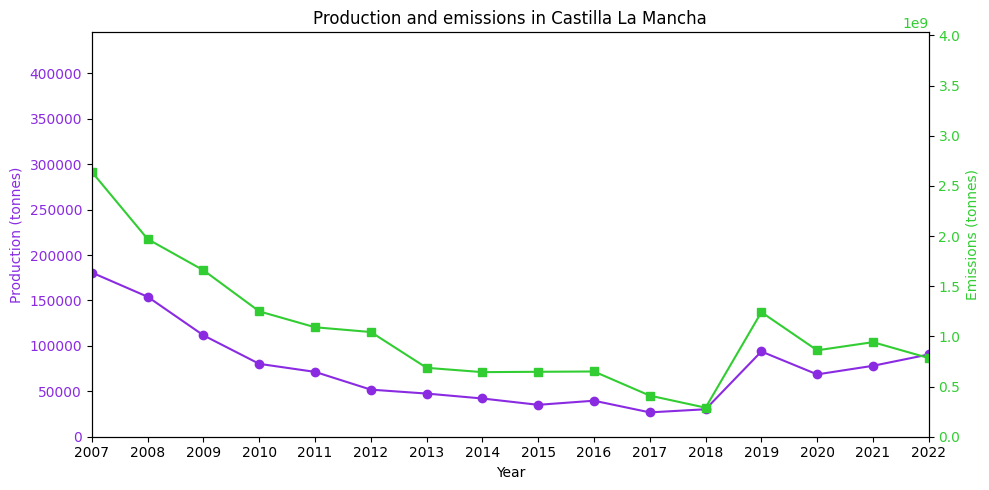

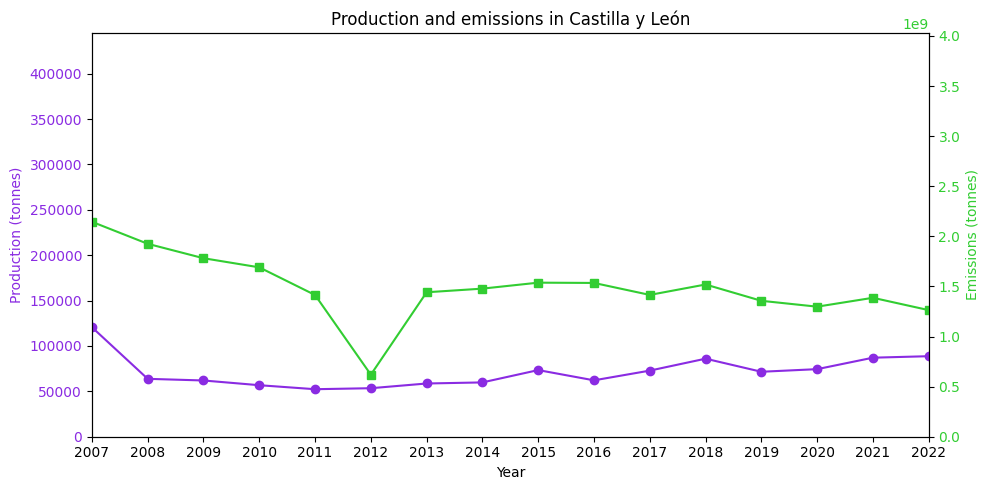

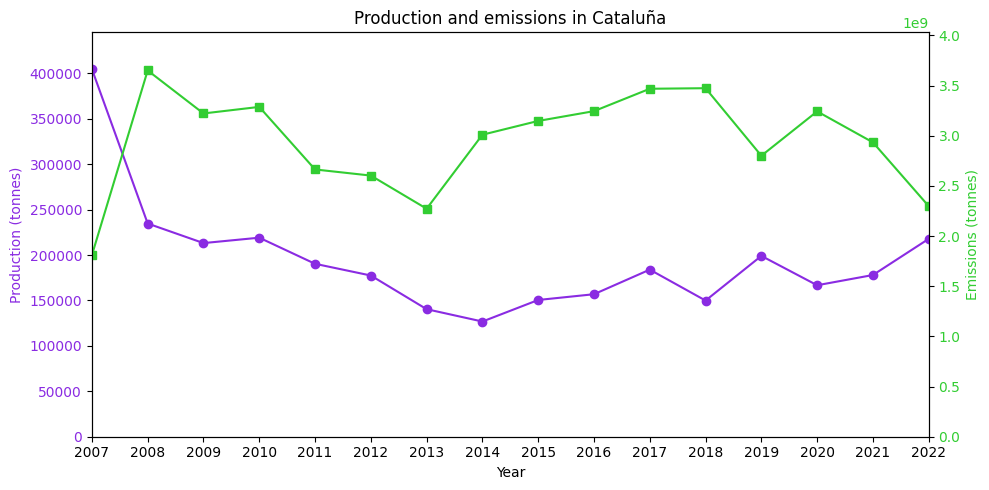

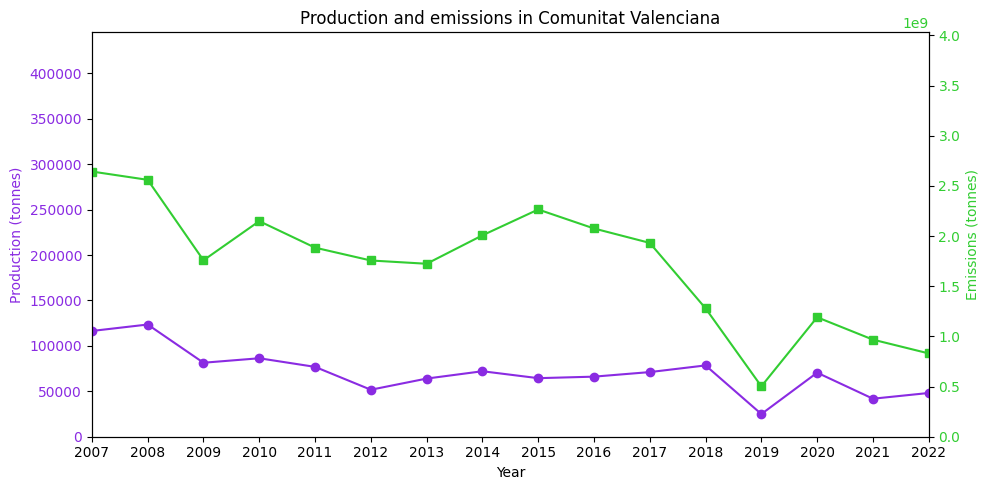

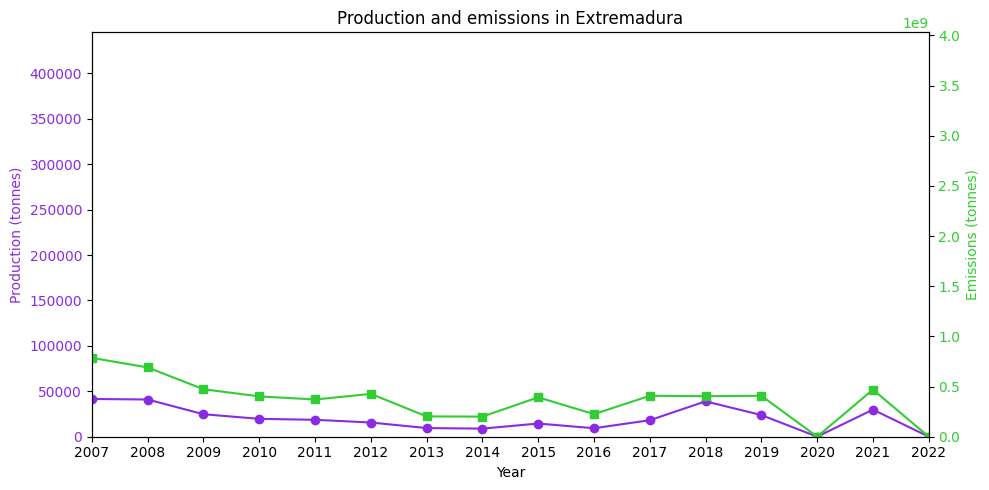

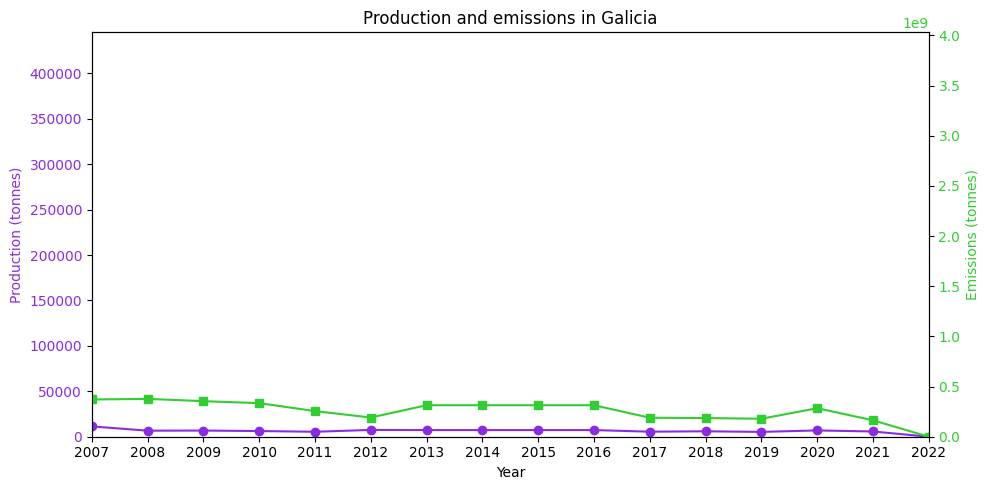

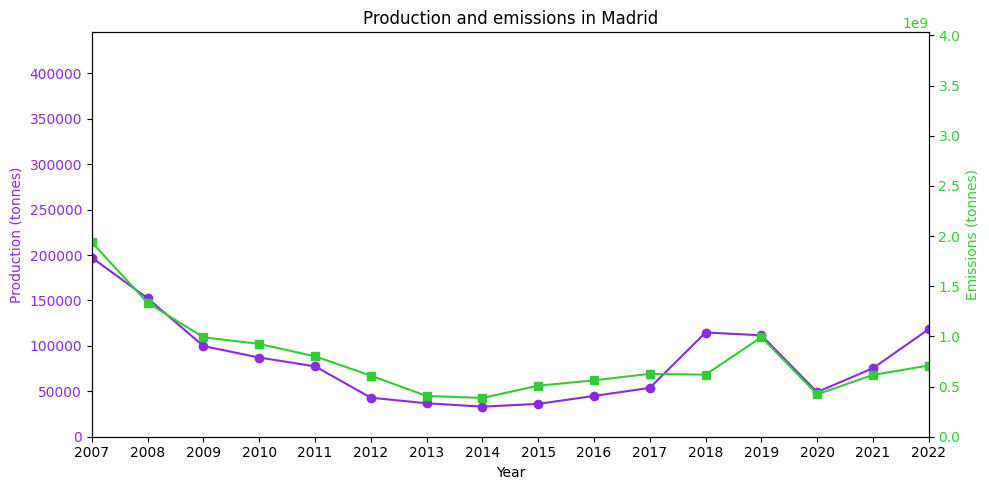

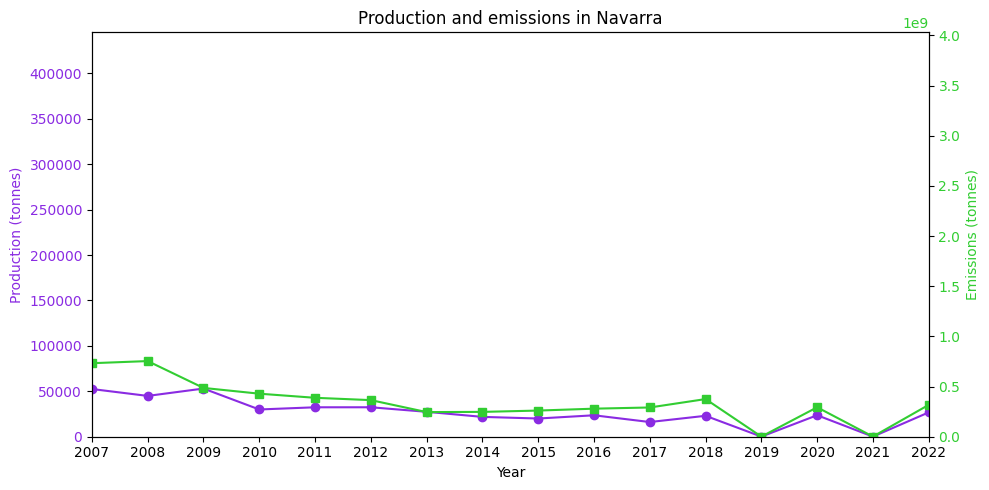

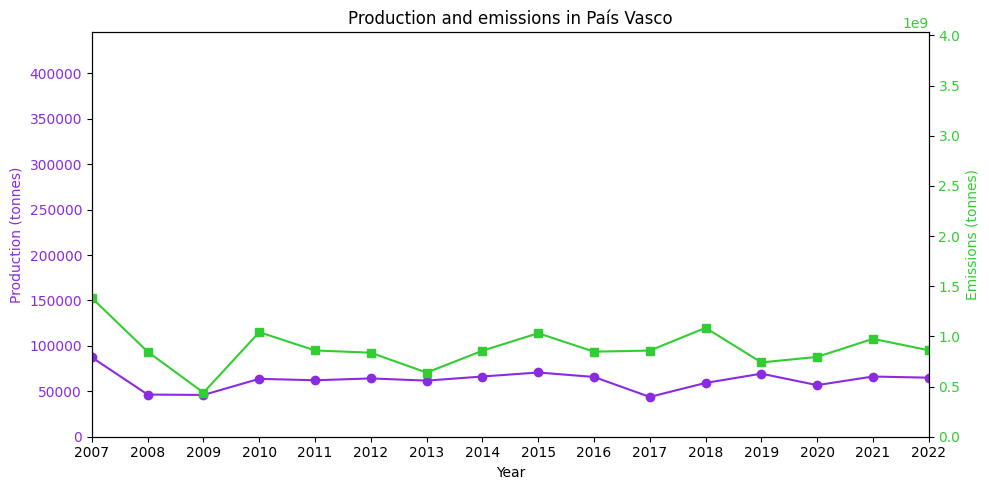

In [ ]:
#get the ccaas by their code as it is unique
ccaas = df_resumen_ccaa["codigo_ccaa"].unique()

#get the max value to maintain the axis the same values so it is easier to compare the plots by ccaa
max_produccion = df_resumen_ccaa["produccion_ccaa"].max()
max_emisiones = df_resumen_ccaa["emisiones_totales_ccaa"].max()

#a graph for each ccaa
for ccaa in ccaas:
    df_ccaa = df_resumen_ccaa[df_resumen_ccaa["codigo_ccaa"] == ccaa]

    nombre_ccaa = df_ccaa["comunidad_autonoma"].iloc[0]
    capacidad_ccaa = df_ccaa["capacidad_total_ccaa"].iloc[0]

    fig, ax1 = plt.subplots(figsize=(10, 5))

    #get the left y axe
    ax1.plot(df_ccaa["año"], df_ccaa["produccion_ccaa"], marker="o", linestyle="-", color="blueviolet", label="Production")
    ax1.axhline(y=capacidad_ccaa, color="indianred", linestyle="dashed", label="Production capacity")  # Línea horizontal

    ax1.set_xlabel("Year")
    ax1.set_ylabel("Production (tonnes)", color="blueviolet")
    ax1.tick_params(axis="y", labelcolor="blueviolet")
    ax1.set_ylim(0, max_produccion * 1.1)

    #get the right y axe
    ax2 = ax1.twinx()
    ax2.plot(df_ccaa["año"], df_ccaa["emisiones_totales_ccaa"], marker="s", linestyle="-", color="limegreen", label="Emissions")
    ax2.set_ylabel("Emissions (tonnes)", color="limegreen")
    ax2.tick_params(axis="y", labelcolor="limegreen")
    ax2.set_ylim(0, max_emisiones * 1.1)

    ax1.set_xlim(2007, 2022)
    ax1.set_xticks(range(2007, 2023))

    plt.title(f"Production and emissions in {nombre_ccaa}")
    fig.tight_layout()
    plt.show()


# Imputation of data in missing years

In [ ]:
#checking which years are missing in which ccaa to impute those values
expected_years = set(range(2007, 2023))
ccaa_with_missing_years = []

for ccaa in df['comunidad_autonoma'].unique():
    years_present = set(df[df['comunidad_autonoma'] == ccaa]['año'].unique())
    missing_years = expected_years - years_present
    if missing_years:
        ccaa_with_missing_years.append((ccaa, sorted(missing_years)))

if ccaa_with_missing_years:
    print("CCAA with missing years:")
    for ccaa, missing in ccaa_with_missing_years:
        print(f"- {ccaa} is missing: {missing}")
else:
    print("No CCAA with missing years. No imputation needed.")

CCAA with missing years:
- Galicia is missing: [2013, 2014, 2015, 2016, 2020]
- Cantabria is missing: [2021]


In [ ]:
new_rows = []

for ccaa, missing_years in ccaa_with_missing_years:
    df_ccaa = df_resumen_ccaa[df_resumen_ccaa["comunidad_autonoma"] == ccaa].copy()

    for año in missing_years:
        df_past = df_ccaa[df_ccaa['año'] < año]

        if df_past.empty:
            continue
        new_row = {
            "año": año,
            "comunidad_autonoma": ccaa,
            "region": df_past["region"].iloc[-1],
            "codigo_ccaa": df_past["codigo_ccaa"].iloc[-1],
            "n_fabricas_ccaa": df_past["n_fabricas_ccaa"].iloc[-1],
            "produccion_ccaa": df_past["produccion_ccaa"].mean(),
            "emisiones_totales_ccaa": df_past["emisiones_totales_ccaa"].mean(),
            "capacidad_total_ccaa": df_past["capacidad_total_ccaa"].mean(),
        }

        new_rows.append(new_row)
        df_ccaa = pd.concat([df_ccaa, pd.DataFrame([new_row])], ignore_index=True)

In [ ]:
df_resumen_ccaa = pd.concat([df_resumen_ccaa, pd.DataFrame(new_rows)], ignore_index=True)
df_resumen_ccaa = df_resumen_ccaa.sort_values(by=["comunidad_autonoma", "año"]).reset_index(drop=True)

In [ ]:
df_resumen_ccaa

,region,año,codigo_ccaa,comunidad_autonoma,n_fabricas_ccaa,emisiones_totales_ccaa,produccion_ccaa,capacidad_total_ccaa
0,ANDALUCIA,2007,A13,Andalucía,6,3.664278e+09,284687.118023,46650000.0
1,ANDALUCIA,2008,A13,Andalucía,6,3.562673e+09,261767.592021,39675000.0
2,ANDALUCIA,2009,A13,Andalucía,6,3.040801e+09,233187.669157,29850000.0
3,ANDALUCIA,2010,A13,Andalucía,6,3.210433e+09,169346.960186,36600000.0
4,ANDALUCIA,2011,A13,Andalucía,6,2.834643e+09,206491.439358,27550000.0
...,...,...,...,...,...,...,...,...
203,NORTE,2018,P5,País Vasco,3,1.085488e+09,59207.228595,16400000.0
204,NORTE,2019,P5,País Vasco,3,7.406115e+08,69387.734366,14225000.0
205,NORTE,2020,P5,País Vasco,3,7.954808e+08,56786.986195,12775000.0
206,NORTE,2021,P5,País Vasco,3,9.758621e+08,66255.290453,16200000.0


# Extracting the dataframe and creating a file

In [ ]:
# import os

# output_dir = '/content/drive/My Drive/DataFrames_Final'

# os.makedirs(output_dir, exist_ok=True)

# dfs = {
#     "production.xlsx": df_produccion,
#     "emissions.xlsx": df_emisiones,
#     "factories.xlsx": df_fabricas,
#     "ccaa_final.xlsx": df_resumen_ccaa
# }

# for filename, df in dfs.items():
#     file_path = os.path.join(output_dir, filename)
#     df.to_excel(file_path, index=False)